## Семинар 5: "Улучшение сходимости нейросетей"

ФИО:

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
%matplotlib inline

## Описание задания:
Вам необходимо реализовать оставшиеся методы из лекции и сравнить их на примере из семинара.

## Задание разделено на следующие части:
1. Реализация Xavier **(1 балл)**

2.1 Реализация DropConnect **(1 балл)**

2.2 Сравнение обучения при использовании Dropout и DropConnect **(1 балл)**

3.1 Реализация LayerNorm **(1 балл)**

3.2 Сравнение обучения при использовании BatchNorm и LayerNorm **(1 балл)**

## Срок выполнения задания:
Данное задание можно сдать без штрафов до 16 октября.


### Часть 1: Инициализация весов

Будем использовать MNIST для обучения:

In [3]:
# Dataloader
to_numpy = lambda x: x.numpy()
transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                    ])
train_dataset = MNIST('.', train=True, download=True, transform=transform)
test_dataset = MNIST('.', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

In [4]:
images_train, labels_train = next(iter(train_loader))

In [5]:
## Usage example:
for X, y in train_loader:
    X = X.view(X.size(0), -1)
    X = X.numpy() ### Converts torch.Tensor to numpy array
    y = y.numpy()
    break

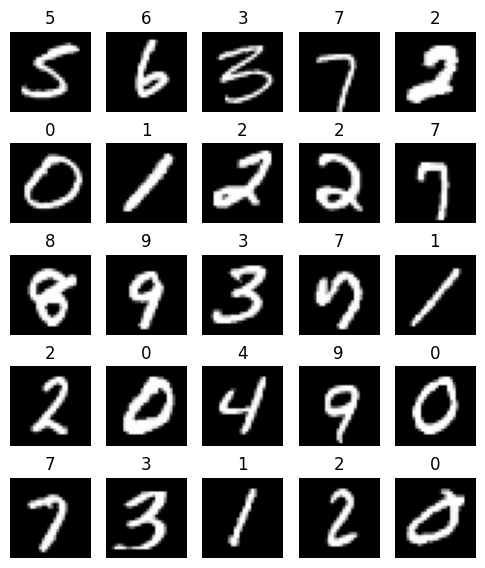

In [6]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(y[i])
    plt.axis('off')

In [21]:
def init_layer(layer, mean=0, std=1):
    # Тут надо быть аккуратным — можно случайно создать копию и менять значения у копии
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weight.normal_(mean=0, std=std)

def init_xavier(layer):
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    lim = np.sqrt(6.0 / (500 + 10))
    weight.uniform_(-lim, lim)

def forward_hook(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)

def backward_hook(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

На вход передаем изображение 28x28, на выходе -- вероятности 10 классов.

In [16]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer(layer_1, 0, 2 / 500)
init_layer(layer_2, 0, 2 / 10)

Соберем все вместе, используя ReLU в качестве функции активации:

In [17]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

#### 1.1 Реализуйте инициализацию Xavier. Сравните ее с He, которая была реализована на семинаре, сделайте выводы. Учтите, что для Xavier необходимо использовать функцию активации nn.Tanh(). **(1 балл)**

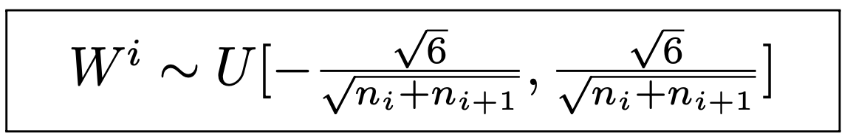

In [18]:
n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.0330709218978882
forward 0.06829530745744705
backward 0.018257416784763336
backward 0.04052047058939934


In [22]:
layer_1 = nn.Linear(28*28, 500)
layer_2 = nn.Linear(500, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_xavier(layer_1)
init_xavier(layer_2)

network = nn.Sequential(
    layer_1,
    nn.Tanh(),
    layer_2
)

n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.0330709218978882
forward 0.7719623446464539
backward 0.018257416784763336
backward 0.009005377069115639


Xavier + Tanh показал себя намного лучше чем He + ReLU при прохождении через слой успешно сохравнив дисперсию 1.03->0.77

## Часть 2: DropConnect

#### 2.1 Реализуйте DropConnect по следующему шаблону: **(1 балл)**

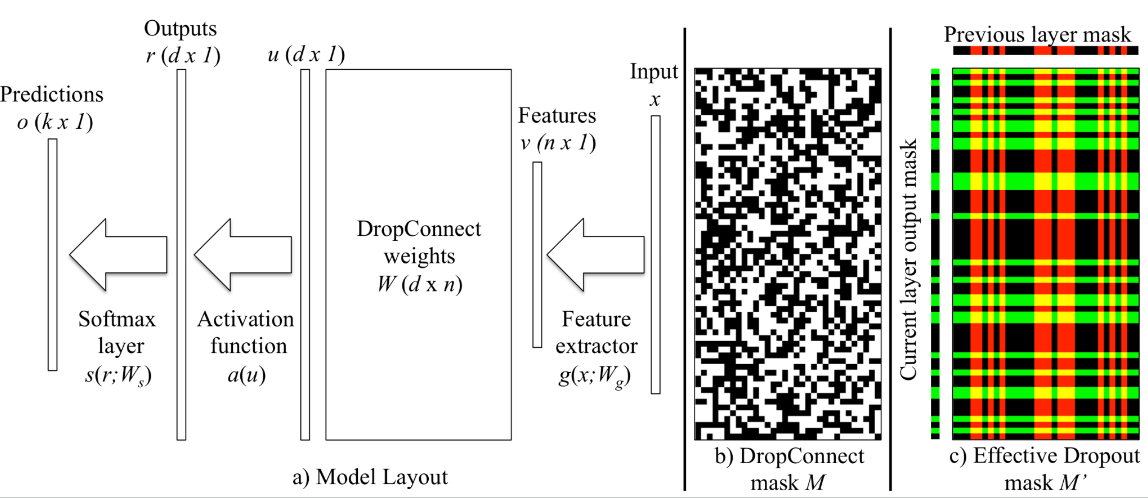

In [23]:
# полезная функция: .bernoulli_(p)
# не забывайте делать requires_grad=False у маски
# помните, что в вычислениях должны участвовать Variable, а не тензоры

class DropConnect(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.5):
        super(DropConnect, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.empty_like(self.linear.weight).bernoulli_(1 - self.p).div_(1 - self.p)
        else:
            mask = torch.ones_like(self.linear.weight)

        mask = mask.data
        output = F.linear(x, self.linear.weight * mask, self.linear.bias)
        return output

Основа для сети, которую будем обучать:

In [25]:
class TestNetwork(nn.Module):
    def __init__(self, final_part):
        super().__init__()

        channels = 1

        self.conv_layers = nn.Sequential(
            nn.Conv2d(channels, 2, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(2, 4, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )

        #input_size = 7 * 7 * 4 = 196
        self.flatten = nn.Flatten()

        self.final_part = final_part

        self.log_softmax = nn.LogSoftmax(1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.final_part(x)
        return self.log_softmax(x)

Добавим несколько слоев в конец сети:

In [26]:
dropout = nn.Sequential(
    nn.Linear(196, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10)
)
network_dropout = TestNetwork(final_part=dropout)

dropconnect = nn.Sequential(
    DropConnect(196, 128, p=0.5),
    nn.ReLU(),
    DropConnect(128, 128, p=0.5),
    nn.ReLU(),
    DropConnect(128, 10, p=0.5)
)
network_dropconnect = TestNetwork(final_part=dropconnect)


Обучим получившуюся сеть:

Epoch: 0	Train Loss: 0.286125	Test Loss: 0.279521
Epoch: 1	Train Loss: 0.183042	Test Loss: 0.180972
Epoch: 2	Train Loss: 0.146550	Test Loss: 0.149823
Epoch: 3	Train Loss: 0.115556	Test Loss: 0.118401
Epoch: 4	Train Loss: 0.097356	Test Loss: 0.104074
Epoch: 5	Train Loss: 0.094558	Test Loss: 0.101548
Epoch: 6	Train Loss: 0.083727	Test Loss: 0.088925
Epoch: 7	Train Loss: 0.077282	Test Loss: 0.083338
Epoch: 8	Train Loss: 0.070850	Test Loss: 0.076204
Epoch: 9	Train Loss: 0.068147	Test Loss: 0.075765
Epoch: 0	Train Loss: 0.279588	Test Loss: 0.264964
Epoch: 1	Train Loss: 0.173536	Test Loss: 0.165346
Epoch: 2	Train Loss: 0.135603	Test Loss: 0.129373
Epoch: 3	Train Loss: 0.116838	Test Loss: 0.111752
Epoch: 4	Train Loss: 0.105147	Test Loss: 0.103710
Epoch: 5	Train Loss: 0.099365	Test Loss: 0.097563
Epoch: 6	Train Loss: 0.094180	Test Loss: 0.093507
Epoch: 7	Train Loss: 0.084737	Test Loss: 0.086490
Epoch: 8	Train Loss: 0.079665	Test Loss: 0.088922
Epoch: 9	Train Loss: 0.077269	Test Loss: 0.079219


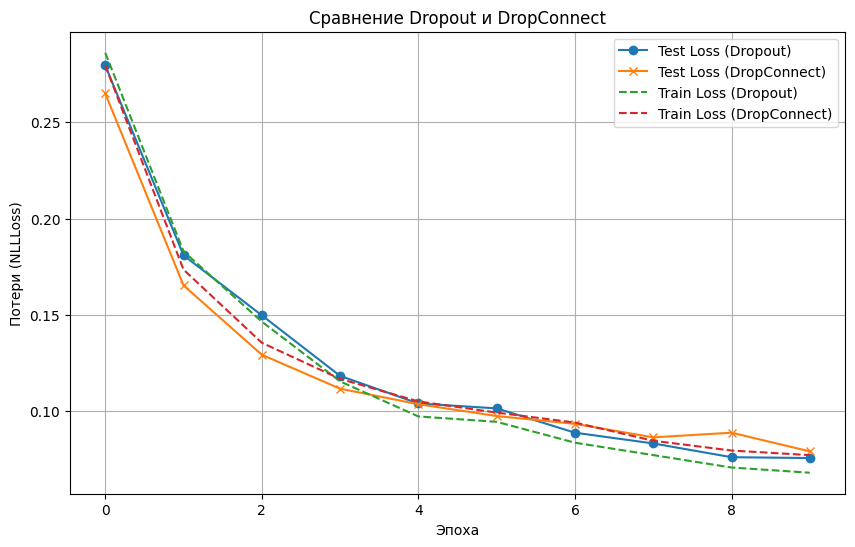

In [28]:
def train_and_evaluate(network, optimizer, loss_fn, device="cuda", epochs=10):
    network.to(device)
    history = {'train_loss': [], 'test_loss': []}
    for epoch in range(epochs):
        network.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            output = network(images)
            loss = loss_fn(output, labels)
            loss.backward()
            optimizer.step()
        network.eval()
        train_losses, test_losses = [], []
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.to(device)
                output = network(images)
                train_losses.append(loss_fn(output, labels).item())
        with torch.no_grad():
            for images_test, labels_test in test_loader:
                images_test = images_test.to(device)
                labels_test = labels_test.to(device)
                output = network(images_test)
                test_losses.append(loss_fn(output, labels_test).item())
        
        avg_train_loss = np.mean(train_losses)
        avg_test_loss = np.mean(test_losses)
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)

        print('Epoch: {}\tTrain Loss: {:.6f}\tTest Loss: {:.6f}'.format(
                epoch, avg_train_loss, avg_test_loss))
    
    return history
loss_fn = nn.NLLLoss()

optimizer_dropout = torch.optim.Adam(network_dropout.parameters(), lr=0.001)
history_dropout = train_and_evaluate(network_dropout, optimizer_dropout, loss_fn, epochs=10)
optimizer_dropconnect = torch.optim.Adam(network_dropconnect.parameters(), lr=0.001)
history_dropconnect = train_and_evaluate(network_dropconnect, optimizer_dropconnect, loss_fn, epochs=10)

plt.figure(figsize=(10, 6))
plt.plot(history_dropout['test_loss'], label='Test Loss (Dropout)', marker='o')
plt.plot(history_dropconnect['test_loss'], label='Test Loss (DropConnect)', marker='x')
plt.plot(history_dropout['train_loss'], label='Train Loss (Dropout)', linestyle='--')
plt.plot(history_dropconnect['train_loss'], label='Train Loss (DropConnect)', linestyle='--')
plt.title('Сравнение Dropout и DropConnect')
plt.xlabel('Эпоха')
plt.ylabel('Потери (NLLLoss)')
plt.legend()
plt.grid(True)
plt.show()

Если смотреть на пунктирные линии то видно что на большем количестве эпох красная пунктирная линиия выше чем зеленая. Из этого можно сказать что DropConnect более сильный регуляризатор. Если говорить в общем то за 10 эпох их сложно сравнить, но что точно понятно, что оба справляются с переобучением 


#### 2.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Dropout между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и DropConnect вместо всех линейных слоев


### Часть 3: Batch Normalization

Наконец, давайте рассмотрим Batch Normalization. Этот слой вычитает среднее и делит на стандартное отклонение. Среднее и дисперсия вычисляются по батчу независимо для каждого нейрона. У этого слоя есть две важные проблемы: его нельзя использовать при обучении с размером батча 1 и он делает элементы батча зависимыми. Давайте реализуем аналог батч нормализации: <a href=https://arxiv.org/pdf/1607.06450.pdf>Layer normalization</a>. В layer normalization среднее и дисперсия вычисляются по активациям нейронов, независимо для каждого объекта.

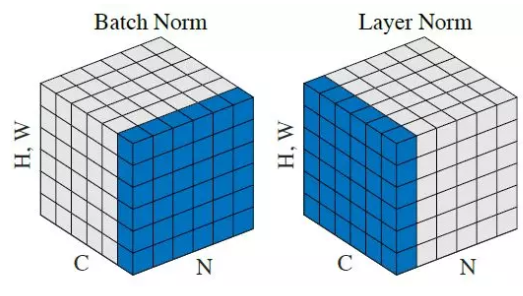

#### 3.1 Реализуйте Layer Normalization **(1 балл)**

In [29]:
# полезные функции: .std(dim), .mean(dim)

class LayerNormalization(nn.Module):
    def __init__(self, features_dim, eps=1e-6):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(features_dim))
        self.shift = nn.Parameter(torch.zeros(features_dim))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        output = self.scale * (x - mean) / (std + self.eps) + self.shift
        return output

#### 3.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Batch normalization между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Layer normalization между всеми слоями

In [30]:
bn = nn.Sequential(
    nn.Linear(196, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
network_bn = TestNetwork(final_part=bn)

ln = nn.Sequential(
    nn.Linear(196, 128),
    LayerNormalization(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    LayerNormalization(128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
network_ln = TestNetwork(final_part=ln)

Epoch: 0	Train Loss: 0.085583	Test Loss: 0.091437
Epoch: 1	Train Loss: 0.057714	Test Loss: 0.075392
Epoch: 2	Train Loss: 0.040420	Test Loss: 0.057046
Epoch: 3	Train Loss: 0.041396	Test Loss: 0.065186
Epoch: 4	Train Loss: 0.025213	Test Loss: 0.055728
Epoch: 5	Train Loss: 0.019376	Test Loss: 0.050356
Epoch: 6	Train Loss: 0.018582	Test Loss: 0.052949
Epoch: 7	Train Loss: 0.017800	Test Loss: 0.052625
Epoch: 8	Train Loss: 0.015127	Test Loss: 0.053723
Epoch: 9	Train Loss: 0.016913	Test Loss: 0.057081
Epoch: 0	Train Loss: 0.132433	Test Loss: 0.134742
Epoch: 1	Train Loss: 0.097393	Test Loss: 0.108634
Epoch: 2	Train Loss: 0.071996	Test Loss: 0.093778
Epoch: 3	Train Loss: 0.055053	Test Loss: 0.083047
Epoch: 4	Train Loss: 0.049080	Test Loss: 0.081882
Epoch: 5	Train Loss: 0.044269	Test Loss: 0.085361
Epoch: 6	Train Loss: 0.037195	Test Loss: 0.078261
Epoch: 7	Train Loss: 0.030679	Test Loss: 0.076062
Epoch: 8	Train Loss: 0.028881	Test Loss: 0.073797
Epoch: 9	Train Loss: 0.029726	Test Loss: 0.080838


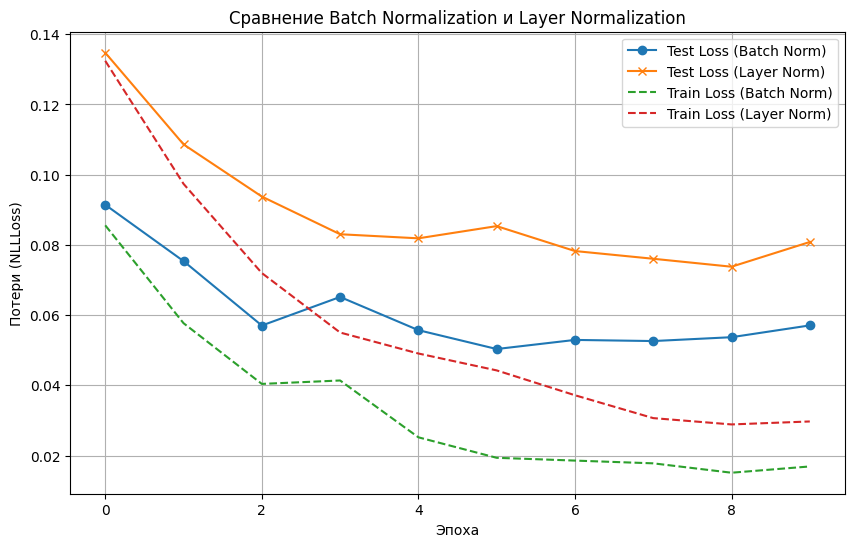

In [35]:

loss_fn = nn.NLLLoss()

optimizer_bn = torch.optim.Adam(network_bn.parameters(), lr=0.001)
history_bn = train_and_evaluate(network_bn, optimizer_bn, loss_fn)

optimizer_ln = torch.optim.Adam(network_ln.parameters(), lr=0.001)
history_ln = train_and_evaluate(network_ln, optimizer_ln, loss_fn)


plt.figure(figsize=(10, 6))
plt.plot(history_bn['test_loss'], label='Test Loss (Batch Norm)', marker='o')
plt.plot(history_ln['test_loss'], label='Test Loss (Layer Norm)', marker='x')
plt.plot(history_bn['train_loss'], label='Train Loss (Batch Norm)', linestyle='--')
plt.plot(history_ln['train_loss'], label='Train Loss (Layer Norm)', linestyle='--')
plt.title('Сравнение Batch Normalization и Layer Normalization')
plt.xlabel('Эпоха')
plt.ylabel('Потери (NLLLoss)')
plt.legend()
plt.grid(True)
plt.show()


По графику видно что Layer Norm обучается значительно медленнее. Batch norm лучше подходит для данной архитектуры. Уже после 2 эпох batch norm достигла lossa такого, до которого layer norm не доходит спустя 10 эпох.  Оба выдали переобучение 